In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('drug200.csv')
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
df.Cholesterol.unique(), df.Drug.unique(), df.BP.unique()

(array(['HIGH', 'NORMAL'], dtype=object),
 array(['drugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object),
 array(['HIGH', 'LOW', 'NORMAL'], dtype=object))

In [4]:
x = df.drop('Drug',axis=1)
y = df.Drug


In [5]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
oe = OrdinalEncoder(categories= [
                      ['M','F'],
                      ['HIGH','LOW','NORMAL'],
                      ['HIGH','NORMAL']                        
                    ])
x[['Sex','BP','Cholesterol']] = oe.fit_transform(x[['Sex','BP','Cholesterol']])
x.shape,y.shape

((200, 5), (200,))

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
x.head(1)

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1.0,0.0,0.0,25.355


In [8]:
dict(zip(oe.categories_[0],range(len(oe.categories_[0]))))

{'M': 0, 'F': 1}

In [9]:
dict(zip(oe.categories_[1],range(len(oe.categories_[1]))))

{'HIGH': 0, 'LOW': 1, 'NORMAL': 2}

In [10]:
dict(zip(oe.categories_[2],range(len(oe.categories_[2]))))

{'HIGH': 0, 'NORMAL': 1}

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score


In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(DecisionTreeClassifier(), x,y,cv = 5,scoring = 'accuracy')
print(score)
print(score.mean())

[1.    1.    1.    0.925 1.   ]
0.985


[Text(0.625, 0.9, 'x[4] <= 14.829\ngini = 0.68\nsamples = 160\nvalue = [17, 13, 11, 43, 76]'),
 Text(0.5, 0.7, 'x[2] <= 0.5\ngini = 0.656\nsamples = 84\nvalue = [17, 13, 11, 43, 0]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[0] <= 50.5\ngini = 0.491\nsamples = 30\nvalue = [17, 13, 0, 0, 0]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 17\nvalue = [17, 0, 0, 0, 0]'),
 Text(0.375, 0.3, 'gini = 0.0\nsamples = 13\nvalue = [0, 13, 0, 0, 0]'),
 Text(0.75, 0.5, 'x[2] <= 1.5\ngini = 0.324\nsamples = 54\nvalue = [0, 0, 11, 43, 0]'),
 Text(0.625, 0.3, 'x[3] <= 0.5\ngini = 0.499\nsamples = 23\nvalue = [0, 0, 11, 12, 0]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 11\nvalue = [0, 0, 11, 0, 0]'),
 Text(0.75, 0.1, 'gini = 0.0\nsamples = 12\nvalue = [0, 0, 0, 12, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 31\nvalue = [0, 0, 0, 31, 0]'),
 Text(0.75, 0.7, 'gini = 0.0\nsamples = 76\nvalue = [0, 0, 0, 0, 76]'),
 Text(0.6875, 0.8, '  False')]

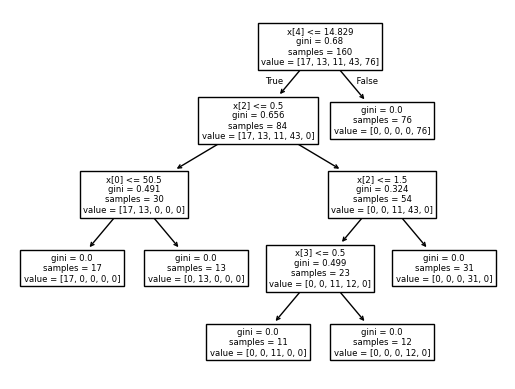

In [14]:
from sklearn.tree import  plot_tree

clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)
plot_tree(clf)

In [15]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [16]:
import graphviz.backend as be
from dtreeviz.trees import model 
from IPython.display import Image, display_svg,SVG

In [18]:
viz_model = model(clf,x_train,y_train,feature_names = df.columns[:-1], target_name = 'Drug', class_names = list(le.classes_))
viz = viz_model.view()
viz.show()

d:\Coding\deep-learning-pytorch\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


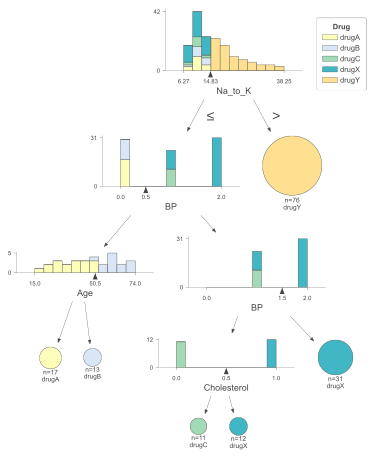

In [19]:
viz